In [1]:
!pip install pyspark


In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("EcommerceAnalysis") \
    .getOrCreate()


In [3]:
from google.colab import files
uploaded = files.upload()

Saving OnlineRetail.csv to OnlineRetail (1).csv


In [4]:
df = spark.read.csv("OnlineRetail.csv", header=True, inferSchema=True)
df.show(5)

+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|12/1/2010 8:26|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|12/1/2010 8:26|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
only showing top 5 rows


In [5]:
df.printSchema()
df.describe().show()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)

+-------+------------------+------------------+--------------------+------------------+---------------+-----------------+------------------+-----------+
|summary|         InvoiceNo|         StockCode|         Description|          Quantity|    InvoiceDate|        UnitPrice|        CustomerID|    Country|
+-------+------------------+------------------+--------------------+------------------+---------------+-----------------+------------------+-----------+
|  count|            541909|            541909|              540455|            541909|         541909|           541909|            406829|     541909|
|   mean|  559965.752026781|27623.240210938104|   

Performing Data cleaning


In [6]:
# Remove null values
df = df.dropna()

# Remove negative or zero quantities
df = df.filter(df["Quantity"] > 0)

# Remove negative prices
df = df.filter(df["UnitPrice"] > 0)

In [7]:
#add Total price column


from pyspark.sql.functions import col

df = df.withColumn("TotalPrice", col("Quantity") * col("UnitPrice"))
df.show()

+---------+---------+--------------------+--------+--------------+---------+----------+--------------+------------------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|        TotalPrice|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+------------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|12/1/2010 8:26|     2.55|     17850|United Kingdom|15.299999999999999|
|   536365|    71053| WHITE METAL LANTERN|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|             20.34|
|   536365|   84406B|CREAM CUPID HEART...|       8|12/1/2010 8:26|     2.75|     17850|United Kingdom|              22.0|
|   536365|   84029G|KNITTED UNION FLA...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|             20.34|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|             20.34|
|   536365|    22752|SET

Performing Analysis

In [8]:
#1.Top selling Products

df.groupBy("Description") \
  .sum("Quantity") \
  .orderBy("sum(Quantity)", ascending=False) \
  .show(10)

+--------------------+-------------+
|         Description|sum(Quantity)|
+--------------------+-------------+
|PAPER CRAFT , LIT...|        80995|
|MEDIUM CERAMIC TO...|        77916|
|WORLD WAR 2 GLIDE...|        54415|
|JUMBO BAG RED RET...|        46181|
|WHITE HANGING HEA...|        36725|
|ASSORTED COLOUR B...|        35362|
|PACK OF 72 RETROS...|        33693|
|      POPCORN HOLDER|        30931|
|  RABBIT NIGHT LIGHT|        27202|
|MINI PAINT SET VI...|        26076|
+--------------------+-------------+
only showing top 10 rows


In [9]:
#2.Top customers

df.groupBy("CustomerID") \
  .sum("TotalPrice") \
  .orderBy("sum(TotalPrice)", ascending=False) \
  .show(10)

+----------+------------------+
|CustomerID|   sum(TotalPrice)|
+----------+------------------+
|     14646| 280206.0199999994|
|     18102|259657.29999999996|
|     17450|194550.78999999995|
|     16446|          168472.5|
|     14911|143825.05999999982|
|     12415| 124914.5299999998|
|     14156|117379.62999999995|
|     17511| 91062.37999999989|
|     16029| 81024.84000000001|
|     12346|           77183.6|
+----------+------------------+
only showing top 10 rows


In [10]:
#3.Revenue by country

df.groupBy("Country") \
  .sum("TotalPrice") \
  .orderBy("sum(TotalPrice)", ascending=False) \
  .show()

+---------------+------------------+
|        Country|   sum(TotalPrice)|
+---------------+------------------+
| United Kingdom| 7308391.554000208|
|    Netherlands| 285446.3399999992|
|           EIRE|265545.89999999903|
|        Germany|228867.14000000025|
|         France|209024.05000000022|
|      Australia|138521.30999999976|
|          Spain| 61577.11000000017|
|    Switzerland|56443.950000000084|
|        Belgium| 41196.34000000001|
|         Sweden| 38378.32999999999|
|          Japan|37416.369999999995|
|         Norway|          36165.44|
|       Portugal|33439.889999999956|
|        Finland|22546.079999999994|
|      Singapore|21279.289999999997|
|Channel Islands|20450.439999999995|
|        Denmark|18955.339999999986|
|          Italy| 17483.23999999999|
|         Cyprus|13590.379999999986|
|        Austria|10198.679999999995|
+---------------+------------------+
only showing top 20 rows


In [12]:
#4.monthly sales Trend

from pyspark.sql.functions import to_timestamp, month

# Convert string to timestamp
df = df.withColumn(
    "InvoiceDate",
    to_timestamp("InvoiceDate", "M/d/yyyy H:mm")
)

# Extract month
df = df.withColumn("Month", month("InvoiceDate"))

# Monthly sales
df.groupBy("Month") \
  .sum("TotalPrice") \
  .orderBy("Month") \
  .show()

+-----+------------------+
|Month|   sum(TotalPrice)|
+-----+------------------+
|    1| 569445.0400000077|
|    2| 447137.3500000165|
|    3|  595500.760000013|
|    4| 469200.3610000132|
|    5| 678594.5600000018|
|    6| 661213.6900000116|
|    7| 600091.0110000141|
|    8|  645343.900000004|
|    9| 952838.3819999964|
|   10|1039318.7899999822|
|   11|1161817.3799999433|
|   12|  1090906.68000002|
+-----+------------------+



Visualization

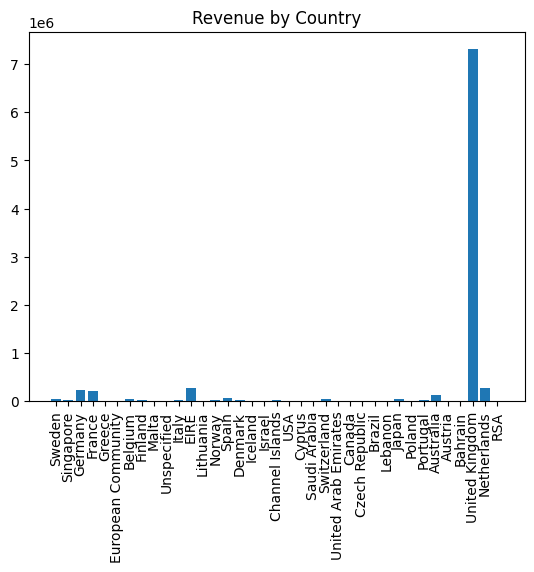

In [13]:
import matplotlib.pyplot as plt

data = df.groupBy("Country").sum("TotalPrice").toPandas()

plt.bar(data["Country"], data["sum(TotalPrice)"])
plt.xticks(rotation=90)
plt.title("Revenue by Country")
plt.show()

In [14]:
#output

df.write.csv("output_data")